In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

import tensorflow as tf

In [3]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

classes = ['Airplane','Automobile','Bird','Cat','Deer','Dog','Frog','Horse','Ship','Truck']

print("Training Images :", x_train.shape)
print("Testing Images :", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1827s 11us/step
Training Images : (50000, 32, 32, 3)
Testing Images : (10000, 32, 32, 3)


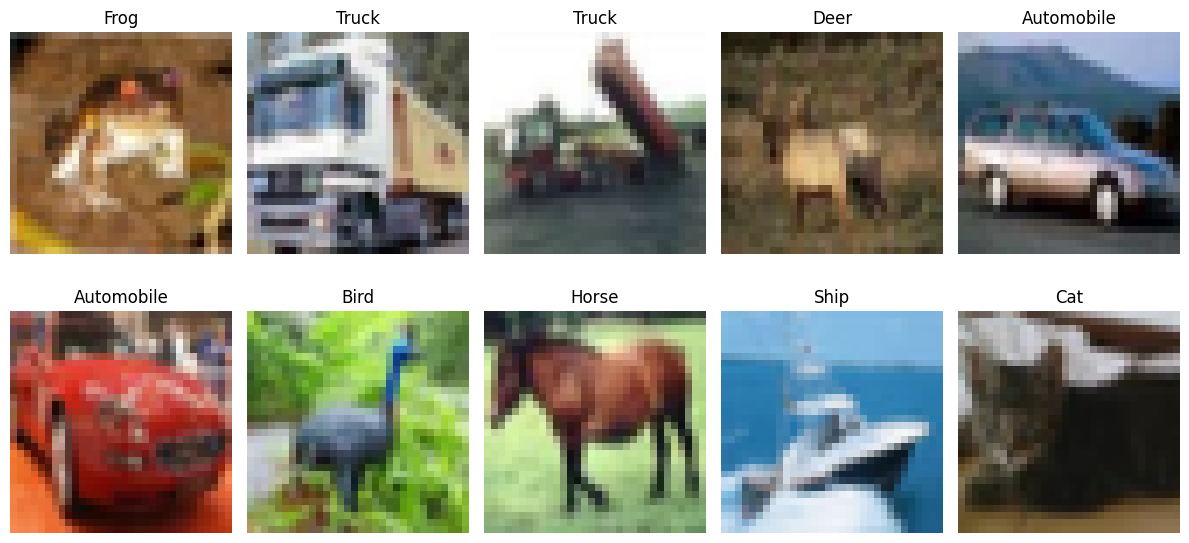

In [4]:
plt.figure(figsize=(12,6))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(classes[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

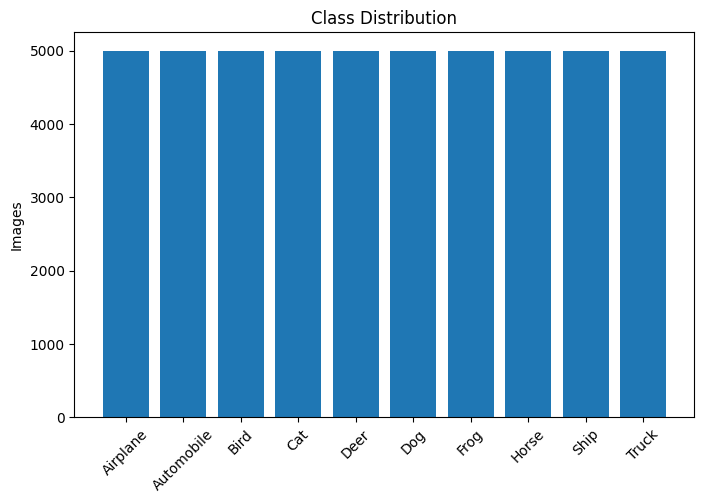

In [5]:
unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(8,5))
plt.bar(classes, counts)
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.ylabel("Images")
plt.show()

In [6]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

y_train_cat = to_categorical(y_train,10)
y_test_cat = to_categorical(y_test,10)

In [7]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',padding='same',input_shape=(32,32,3)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64,(3,3),activation='relu',padding='same'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128,(3,3),activation='relu',padding='same'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(10,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
history = model.fit(
    x_train,
    y_train_cat,
    epochs=15,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 108s 169ms/step - accuracy: 0.3640 - loss: 1.7144 - val_accuracy: 0.5123 - val_loss: 1.3518
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 102s 163ms/step - accuracy: 0.5311 - loss: 1.3120 - val_accuracy: 0.6064 - val_loss: 1.1059
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 141s 162ms/step - accuracy: 0.5978 - loss: 1.1390 - val_accuracy: 0.6471 - val_loss: 0.9961
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 141s 161ms/step - accuracy: 0.6415 - loss: 1.0207 - val_accuracy: 0.6839 - val_loss: 0.8973
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 102s 163ms/step - accuracy: 0.6687 - loss: 0.9428 - val_accuracy: 0.7016 - val_loss: 0.8548
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 102s 164ms/step - accuracy: 0.7006 - loss: 0.8590 - val_accuracy: 0.7195 - val_loss: 0.8002
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 144s 168ms/step - accuracy: 0.7207 - loss: 0.8001 - val_accuracy: 0.7308 - val_loss: 0.7770
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 101s 161ms/step - accuracy: 0.7361 -

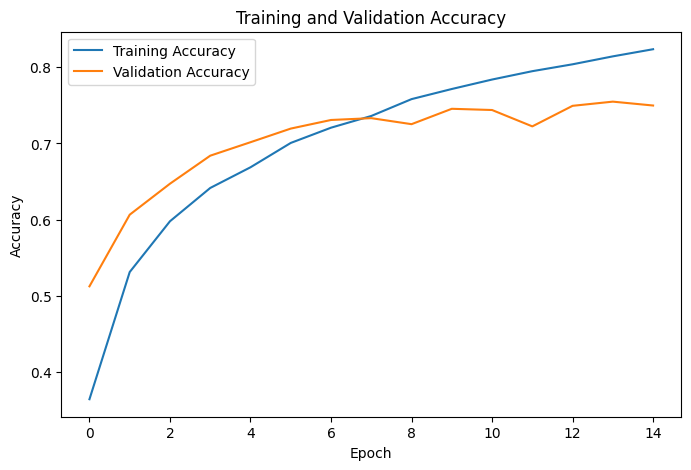

In [11]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

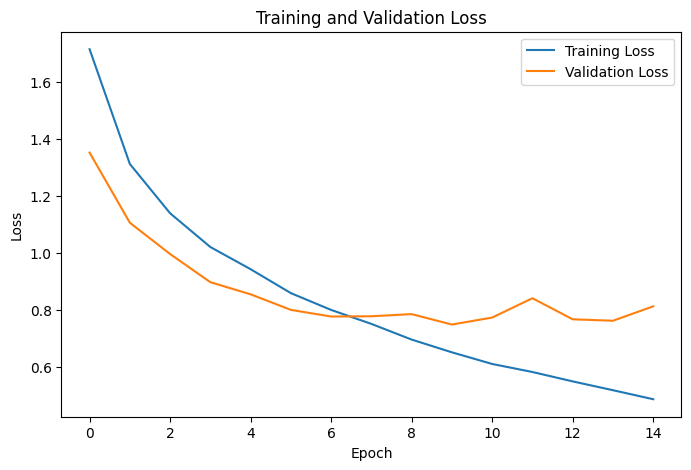

In [12]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [13]:
loss, accuracy = model.evaluate(x_test, y_test_cat, verbose=0)

print("Test Loss :", round(loss,4))
print("Test Accuracy :", round(accuracy*100,2),"%")

Test Loss : 0.8288
Test Accuracy : 74.43 %


In [14]:
pred = model.predict(x_test, verbose=0)

y_pred = np.argmax(pred, axis=1)
y_true = y_test.flatten()

In [15]:
p = precision_score(y_true, y_pred, average='weighted')
r = recall_score(y_true, y_pred, average='weighted')
f = f1_score(y_true, y_pred, average='weighted')

print("Precision :", round(p,4))
print("Recall :", round(r,4))
print("F1 Score :", round(f,4))

Precision : 0.7462
Recall : 0.7443
F1 Score : 0.7433


In [16]:
print(classification_report(y_true, y_pred, target_names=classes))

              precision    recall  f1-score   support

    Airplane       0.78      0.80      0.79      1000
  Automobile       0.84      0.86      0.85      1000
        Bird       0.68      0.63      0.65      1000
         Cat       0.59      0.52      0.55      1000
        Deer       0.77      0.63      0.69      1000
         Dog       0.57      0.71      0.63      1000
        Frog       0.81      0.80      0.80      1000
       Horse       0.80      0.79      0.80      1000
        Ship       0.86      0.85      0.86      1000
       Truck       0.77      0.86      0.81      1000

    accuracy                           0.74     10000
   macro avg       0.75      0.74      0.74     10000
weighted avg       0.75      0.74      0.74     10000



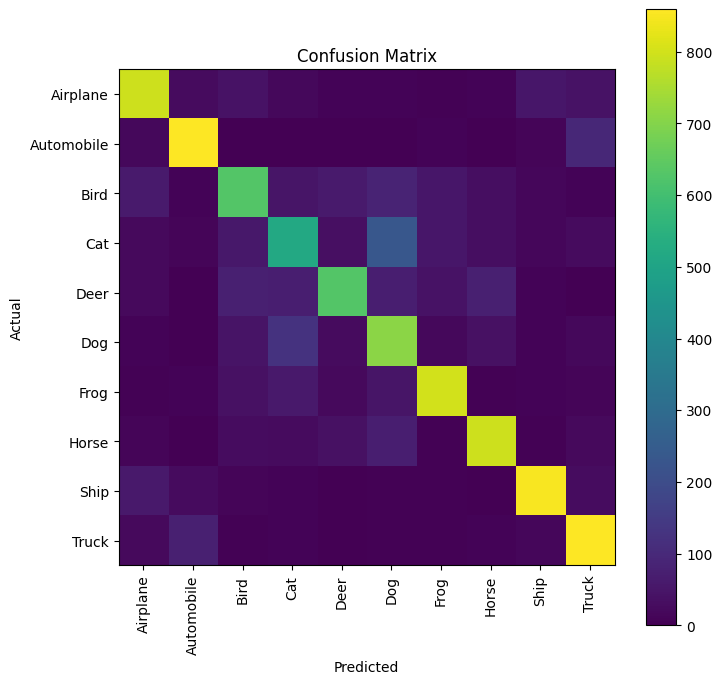

In [17]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,8))
plt.imshow(cm)
plt.colorbar()

plt.xticks(range(10), classes, rotation=90)
plt.yticks(range(10), classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

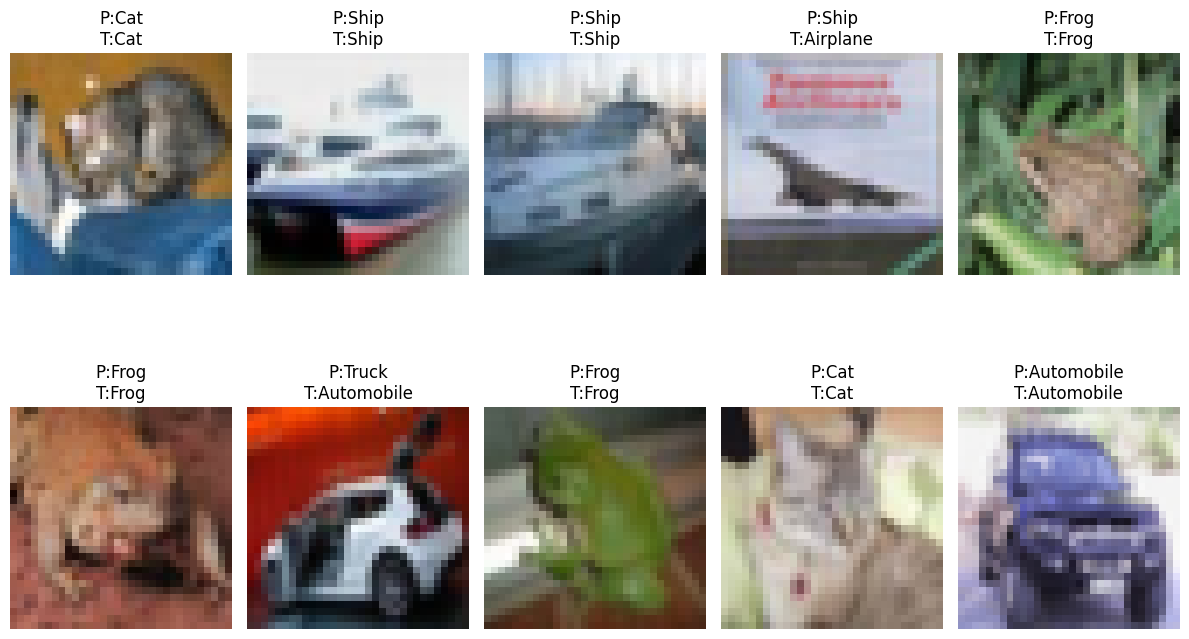

In [18]:
plt.figure(figsize=(12,8))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i])
    plt.title("P:"+classes[y_pred[i]]+"\nT:"+classes[y_true[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,070,432 (4.08 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 713,622 (2.72 MB)

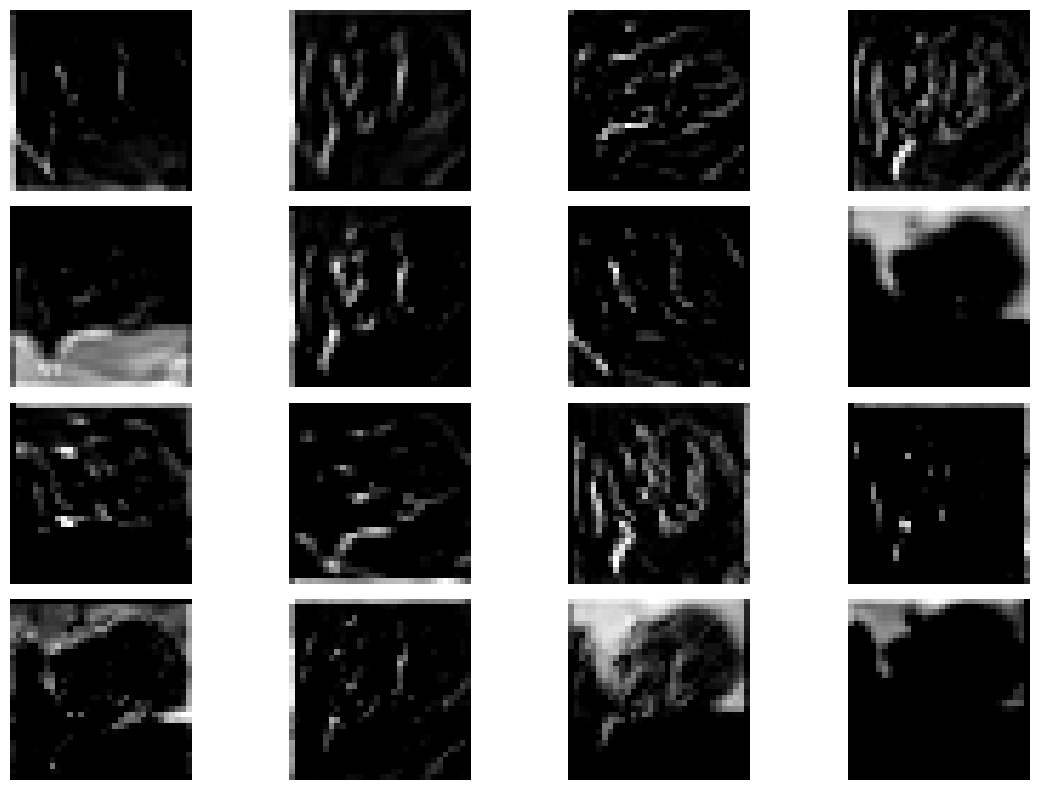

In [21]:
feature_model = tf.keras.Model(
    inputs=model.inputs,
    outputs=model.layers[0].output
)

feature = feature_model.predict(x_test[:1], verbose=0)

plt.figure(figsize=(12,8))

for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(feature[0,:,:,i], cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [22]:
print("Trainable Parameters\n")

for layer in model.layers:
    print(layer.name, ":", layer.count_params())

Trainable Parameters

conv2d : 896
max_pooling2d : 0
conv2d_1 : 18496
max_pooling2d_1 : 0
conv2d_2 : 73856
max_pooling2d_2 : 0
flatten : 0
dense : 262272
dropout : 0
dense_1 : 1290


In [23]:
print("Final Test Accuracy :", round(accuracy*100,2),"%")

Final Test Accuracy : 74.43 %
